In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import torch
import torchvision.transforms as T
import PIL.Image as Image

/home/mattia/miniconda3/envs/keypoint_factory/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
image_path = "DJI_0013_frame_000023.jpg"
img = Image.open(image_path).convert("RGB")

img_tensor = T.ToTensor()(img).cuda()[None]
print(img_tensor.shape)

In [ ]:
from extractors.canny import CannyEdgeDetector

edge_extractor = CannyEdgeDetector(device="cuda", **{"sigma": 3.0})
edges = edge_extractor(img_tensor)
edges.shape, edges.device

# frustums

In [ ]:
plt.figure(figsize=(12, 6))
plt.imshow(~(edges.squeeze().cpu().bool()), cmap="gray")
plt.show()

In [ ]:
import pycolmap 

rec = pycolmap.Reconstruction("sparse/0")

In [ ]:
rec.cameras[1].model.name

In [ ]:
for img in rec.images.values():
    break
rec.cameras[img.camera_id].calibration_matrix()

In [ ]:
import h5py
import torch
import pycolmap
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm

def load_reconstruction(recon_path):
    """Load COLMAP reconstruction."""
    recon = pycolmap.Reconstruction(recon_path)
    cams = recon.cameras
    imgs = recon.images
    id_to_name = {img.image_id: img.name for img in imgs.values()}
    return recon, cams, imgs, id_to_name


def estimate_depth_limits(depth_dir, image_name, default_near=0.1, default_far=5.0):
    """
    Estimate z_near and z_far from per-image depth map (.npy or .exr).
    If not found, return defaults.
    """
    depth_path = Path(depth_dir) / (image_name.split('.')[0] + '.h5')
    if not depth_path.exists():
        print(f"Depth map not found for {depth_path}, using defaults: near={default_near}, far={default_far}")
        return default_near, default_far

    # load h5 file
    depth = h5py.File(depth_path, "r")["depth"][()]
    valid = depth[np.isfinite(depth)]

    if valid.size < 10:
        return default_near, default_far
    
    near = np.percentile(valid, 5)
    far = np.percentile(valid, 95)

    return float(near), float(far)


def compute_frustum_corners(K, width, height, z_near, z_far, R, t, device):
    """Compute 8 frustum corners in world coordinates."""
    corners_px = torch.tensor([
        [0, 0, 1],
        [width, 0, 1],
        [width, height, 1],
        [0, height, 1]
    ], dtype=torch.float32, device=device)

    invK = torch.inverse(K)
    near_pts = (invK @ corners_px.T).T * z_near
    far_pts = (invK @ corners_px.T).T * z_far
    pts_cam = torch.cat([near_pts, far_pts], dim=0)
    # Xw = R^T (Xc - t)
    Xw = (R.T @ (pts_cam.T - t.reshape(3, 1))).T
    return Xw


def aabb_from_points(points):
    """Compute axis-aligned bounding box."""
    return points.min(dim=0).values, points.max(dim=0).values


def aabb_overlap(a_min, a_max, b_min, b_max):
    """Check if AABBs intersect."""
    return torch.all(a_min <= b_max) and torch.all(b_min <= a_max)


def build_view_graph_from_frustums(
    recon_path,
    depth_dir=None,
    z_near_default=0.1,
    z_far_default=5.0,
    max_view_angle_deg=75.0,
    distance_factor=2,
    verbose=True,
):
    """
    Compute view-graph image pairs by frustum intersection, 
    with tighter geometric filtering.
    Args:
        recon_path: path to COLMAP reconstruction folder
        depth_dir: optional path to per-image depth maps (for better near/far estimation)
        device: torch device
        z_near_default: default near plane distance
        z_far_default: default far plane distance
        max_view_angle_deg: maximum allowed view-direction angle difference between cameras. (To reduce pairs: lower the value (e.g., 20°)
        distance_factor: maximum allowed distance between camera centers as a factor of scene size (To reduce pairs: set to 1.0-1.5, to increase pairs: set to 3.0-4.0.)
    """

    recon, cams, imgs, id_to_name = load_reconstruction(recon_path)
    device = "cpu"

    frustums = {}
    aabbs = {}
    centers = {}
    directions = {}

    if verbose is True:
        print("Building camera frustums and computing metadata...")
        bar = tqdm(imgs.values())
    else:
        bar = imgs.values()

    for img in bar:
        cam = cams[img.camera_id]
        K = torch.tensor(cam.calibration_matrix(), dtype=torch.float32, device=device)
        R = torch.tensor(img.cam_from_world.rotation.matrix(), dtype=torch.float32, device=device)
        t = torch.tensor(img.cam_from_world.translation, dtype=torch.float32, device=device)

        if depth_dir:
            z_near, z_far = estimate_depth_limits(depth_dir, img.name)
        else:
            z_near, z_far = z_near_default, z_far_default

        # shrink far plane slightly (avoid wide skinny cones)
        z_far *= 0.9

        corners = compute_frustum_corners(K, cam.width, cam.height, z_near, z_far, R, t, device)
        aabbs[img.image_id] = aabb_from_points(corners)
        frustums[img.image_id] = corners

        # camera center in world = -R^T t
        c_world = -(R.T @ t)
        centers[img.image_id] = c_world
        # camera forward vector in world
        d_world = R.T @ torch.tensor([0., 0., 1.], device=device)
        directions[img.image_id] = d_world / torch.norm(d_world)

    ids = list(imgs.keys())
    pairs = []

    cos_angle_thresh = torch.cos(torch.deg2rad(torch.tensor(max_view_angle_deg, device=device)))

    if verbose:
        print(f"\nChecking {len(ids)} cameras for tight frustum overlaps...")

    for i_idx, i in enumerate(ids):
        a_min, a_max = aabbs[i]
        ci, di = centers[i], directions[i]
        for j in ids[i_idx + 1:]:
            b_min, b_max = aabbs[j]
            cj, dj = centers[j], directions[j]

            # Step 1: AABB intersection (coarse)
            if not aabb_overlap(a_min, a_max, b_min, b_max):
                continue

            # Step 2: view direction consistency
            cos_angle = torch.dot(di, dj)
            if cos_angle < cos_angle_thresh:
                continue  # too divergent (e.g., opposite sides)

            # Step 3: distance filter
            dist = torch.norm(ci - cj)
            scene_scale = torch.norm(a_max - a_min)
            if dist > distance_factor * scene_scale:
                continue

            pairs.append([i, j])

    if verbose:
        print(f"\nFound {len(pairs):,} tight overlapping pairs.")
    return pairs, id_to_name


def save_pairs_to_file(pairs, id_to_name, output_file="pairs.txt"):
    """Save view-graph pairs to text file (COLMAP-style)."""
    out_pairs = []
    for i, j in pairs:
        sorted_ij = sorted([id_to_name[i], id_to_name[j]])
        out_pairs.append([sorted_ij[0], sorted_ij[1]])
    
    if output_file is None:
        with open("pairs_debug.txt", "w") as f:
            for i, j in out_pairs:
                f.write(f"{i} {j}\n")

    # sort pairs by first image name and then second image name
    out_pairs = sorted(out_pairs, key=lambda x: (x[0], x[1]))

    return out_pairs


In [ ]:
# Define paths
recon_path = "/home/mattia/Desktop/datasets/mydataset/data/udine_castello_fagagna/colmap/sparse/0"
depth_dir = "/home/mattia/Desktop/datasets/mydataset/data/udine_castello_fagagna/depth"

# Run view-graph building
pairs, id_to_name = build_view_graph_from_frustums(
    recon_path,
    depth_dir=None, # not changing much, so we skip depth maps for speed
    verbose=True,
)

# Optionally save
pairs = save_pairs_to_file(pairs, id_to_name, None) #"sparse/pairs.txt")

pairs[:5]

In [ ]:
# # load pairs
# with open("sparse/pairs.txt", "r") as f:
#     pairs = [line.strip().split() for line in f.readlines()]    

for n in [15, 30, 50]:
    # load viewgraph_15.txt
    with open(f"/home/mattia/Desktop/datasets/mydataset/data/udine_castello_fagagna/colmap/viewgraph_{n}.txt", "r") as f:
        viewgraph = [line.strip().split()[:2] for line in f.readlines()]

    # Convert to tuple-based set once
    viewgraph_set = {tuple(p) for p in viewgraph}
    overlap_pairs = {(a, b) for (a, b) in pairs if (a, b) in viewgraph_set or (b, a) in viewgraph_set}
    print(f"Viewgraph pairs ({n}): {len(viewgraph):,}, Found pairs: {len(pairs):,}, Correct pairs found: {len(overlap_pairs):,} ({len(overlap_pairs)/len(viewgraph)*100:.2f}%)")


In [ ]:
import os

res = {}
for scene in tqdm(sorted(os.listdir("/home/mattia/Desktop/datasets/mydataset/data"))):

    # Define paths
    recon_path = f"/home/mattia/Desktop/datasets/mydataset/data/{scene}/colmap/sparse/0"

    # Run view-graph building
    pairs, id_to_name = build_view_graph_from_frustums(
        recon_path,
        depth_dir=None,
        verbose=False,
    )

    pairs = save_pairs_to_file(pairs, id_to_name, None)  #"sparse/pairs.txt")

    # load viewgraph_30.txt
    with open(f"/home/mattia/Desktop/datasets/mydataset/data/{scene}/colmap/viewgraph_30.txt", "r") as f:
        viewgraph = [line.strip().split()[:2] for line in f.readlines()]

    # Convert to tuple-based set once
    viewgraph_set = {tuple(p) for p in viewgraph}
    overlap_pairs = {(a, b) for (a, b) in pairs if (a, b) in viewgraph_set or (b, a) in viewgraph_set}
    # print(f"Viewgraph pairs ({n}): {len(viewgraph):,}, Found pairs: {len(pairs):,}, Correct pairs found: {len(overlap_pairs):,} ({len(overlap_pairs)/len(viewgraph)*100:.2f}%)")

    res[scene] = {
        "viewgraph_pairs": len(viewgraph),
        "found_pairs": len(pairs),
        "overlap_pairs": len(overlap_pairs),
    }

In [ ]:
import pandas as pd

df = pd.DataFrame.from_dict(res, orient="index")
df["correctness"] = df["overlap_pairs"] / df["viewgraph_pairs"]
df

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 6))
plt.bar(df.index, df["correctness"])
# plot median and avg lines
plt.axhline(y=df["correctness"].mean(), color='r', linestyle='--', label='Average')
plt.axhline(y=df["correctness"].median(), color='g', linestyle='--', label='Median')
plt.legend()
plt.xticks(rotation=90)
plt.ylabel("Correctness")
plt.show()

# testing adjuster


In [2]:
input_model = "/home/mattia/Desktop/Repos/vggt/wrapper_output/vienna_state_opera/sparse"

import pycolmap
reconstruction = pycolmap.Reconstruction(input_model)
reconstruction.find_image_with_name("13/IMG_4697_frame_000001.jpg").cam_from_world

Rigid3d(rotation_xyzw=[-0.000783403, 0.000655326, -0.000392925, 0.999999], translation=[5.78952e-05, -6.10562e-07, 0.00249547])

In [3]:
from adjuster import Adjuster
adjuster = Adjuster(
    reconstruction = "/home/mattia/Desktop/Repos/vggt/wrapper_output/vienna_state_opera/sparse",
    images_path = "/home/mattia/Desktop/datasets/mydataset/data/vienna_state_opera/frames",
    depths_path = "/home/mattia/Desktop/Repos/vggt/wrapper_output/vienna_state_opera/sparse/depth_maps",
    single_camera_per_folder=True, 
    load_with_pad=False,
    lr=1e-3,
)

CannyEdgeDetector initialized with low_threshold=0.15, high_threshold=0.25, hysteresis=True, kernel_size=9, sigma=7.0, device=cuda
Found 106 images in /home/mattia/Desktop/datasets/mydataset/data/vienna_state_opera/frames


Filtering viewgraph by reprojection: 100%|██████████| 5541/5541 [00:12<00:00, 426.76it/s]


Total parameters to optimize: 750


In [12]:
out = adjuster(
    max_pairs=512,
    max_steps=1,
)

Quick mode ON. Down-sampling viewgraph from 3,146 to 512 pair. 


Adjusting poses and depth maps: 100%|██████████| 1/1 [00:03<00:00,  3.04s/it, loss=6.692319]


                      Summary                       
----------------------------------------------------
Stage                           Time (s)         %
----------------------------------------------------
viewgraph                           0.21       0.5%
load_images                         1.17       2.5%
load_poses_and_intrinsics           0.02       0.1%
load_depth_maps                     0.07       0.2%
extract_edges                       1.13       2.4%
compute_distance_fields             4.60       9.9%
filter_viewgraph                   12.99      27.9%
total_optimization                 26.37      56.6%
----------------------------------------------------
Total                              46.56
----------------------------------------------------
Initial loss:                               7.267574
Final loss:                                 6.692319
Loss reduction:                             0.575254
Total steps:                                       9


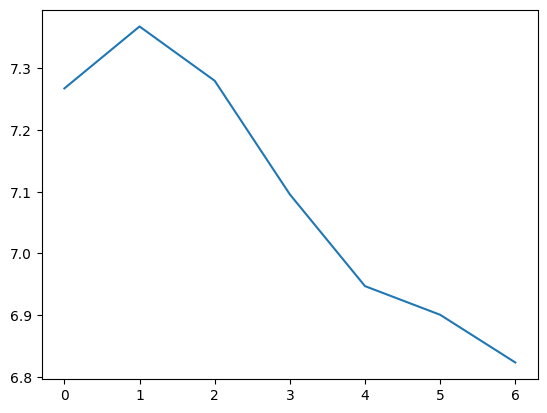

In [10]:
from matplotlib import pyplot as plt
plt.plot(adjuster.loss_list)


In [ ]:
import pycolmap
import numpy as np
import os

def build_reconstruction_from_data(images, intrinsics, scale=1.0):
    """
    Create a pycolmap.Reconstruction from images and intrinsics dictionaries.
    
    Args:
        images: dict with image_name -> {P: Pose, cam_id: int, ...}
        intrinsics: dict with cam_id -> Camera
        scale: scaling factor for translation vectors
    """
    # Create empty reconstruction
    reconstruction = pycolmap.Reconstruction()
    
    # 1. Add cameras
    for cam_id, camera in intrinsics.items():
        # Get camera parameters as numpy array
        params = camera.params.detach().cpu().numpy()
        
        # Apply scaling to focal lengths if needed
        if camera.model == "PINHOLE":
            # Scale fx, fy (but not cx, cy which are pixel coordinates)
            params = params.copy()
            params[0] *= scale  # fx
            params[1] *= scale  # fy
            model = pycolmap.CameraModelId.PINHOLE
        elif camera.model == "SIMPLE_PINHOLE":
            # Scale f (but not cx, cy)
            params = params.copy()
            params[0] *= scale  # f
            model = pycolmap.CameraModelId.SIMPLE_PINHOLE
        else:
            raise ValueError(f"Unsupported camera model: {camera.model}")
        
        # Get image dimensions (assuming all images with this cam_id have same size)
        # Find first image with this cam_id - don't convert cam_id yet
        sample_image = next((img for img in images.values() if img["cam_id"] == cam_id), None)
        
        if sample_image is None:
            print(f"Warning: No images found for camera {cam_id}, skipping...")
            continue
            
        height, width = sample_image["image"].shape[-2:]
        
        # Scale image dimensions
        width = int(width * scale)
        height = int(height * scale)
        
        # Convert cam_id to int for COLMAP
        cam_id_int = int(cam_id) if isinstance(cam_id, str) else cam_id
        
        # Create and register camera
        cam = pycolmap.Camera(
            model=model,
            width=width,
            height=height,
            params=params,
            camera_id=cam_id_int
        )
        reconstruction.add_camera(cam)
    
    # 2. Add images (poses)
    for image_id, (image_name, image_data) in enumerate(images.items(), start=1):
        pose = image_data["P"]
        cam_id = image_data["cam_id"]
        
        # Convert cam_id to int for COLMAP
        cam_id_int = int(cam_id) if isinstance(cam_id, str) else cam_id
        
        # Get rotation matrix and translation
        q = pose.q.detach().cpu().numpy()
        t = pose.t.detach().cpu().numpy()
        
        # Apply scaling to translation
        t = t * scale

        # use xyzw -> wxyz
        q = np.roll(q, shift=3)

        # Create image
        img = pycolmap.Image(
            id=image_id,
            name=image_name,
            camera_id=cam_id_int,
            cam_from_world=pycolmap.Rigid3d(
                rotation=pycolmap.Rotation3d(q),
                translation=t
            )
        )
        reconstruction.add_image(img)
    
    # 3. Info reconstruction
    print(f"Cameras: {len(reconstruction.cameras)}")
    print(f"Images: {len(reconstruction.images)}")
    print(f"Points3D: {len(reconstruction.points3D)}")
    print(f"Scale factor: {scale}")
    
    return reconstruction

In [ ]:
# After your optimization loop
reconstruction = build_reconstruction_from_data(
    images, 
    intrinsics, 
)

out_path = "optimized_reconstruction"
os.makedirs(out_path, exist_ok=True)
reconstruction.write_text(out_path)

In [ ]:
.

In [ ]:
from mylib.plot import plot_imgs

print(len(viewgraph))
i,j = viewgraph[2000]
print(i, j)

i, j = '13/IMG_4697_frame_000001.jpg', '13/IMG_4697_frame_000003.jpg'

plot_imgs([images[i]['image'].permute(1,2,0).cpu(), images[j]['image'].permute(1,2,0).cpu()])

In [ ]:
plot_imgs([images[i]['edges_map'], images[j]['edges_map']], cmap="gray")

In [ ]:
plot_imgs([images[i]['depth'], images[j]['depth']], cmap="plasma")

In [ ]:
# plot_imgs([images[i]['dt_field'], images[j]['dt_field']], cmap="plasma")

In [ ]:
x1,y1,x2,y2,h,w = [int(x) for x in images[i]['coords']]
img1 = images[i]['image'][:, y1:y2, x1:x2]
img2 = images[j]['image'][:, y1:y2, x1:x2]
edge1 = images[i]['edges_map'][y1:y2, x1:x2]
edge2 = images[j]['edges_map'][y1:y2, x1:x2]
Z1 = images[i]['depth'][y1:y2, x1:x2][None]
Z2 = images[j]['depth'][y1:y2, x1:x2][None]

edge1.shape, edge2.shape, img1.shape, img2.shape, Z1.shape, Z2.shape

In [ ]:
from helpers.reprojection import compute_121_reprojection

data = {
    'P0': images[i]['P'].projection_matrix()[None], 
    'P1': images[j]['P'].projection_matrix()[None],
    'K0': intrinsics[images[i]['cam_id']].intrinsic_matrix()[None],  
    'K1': intrinsics[images[j]['cam_id']].intrinsic_matrix()[None],
    'depth0': Z1, 
    'depth1': Z2
}

kpts1, kpts2, tot = compute_121_reprojection(
    data,
    img1, img2,
    verbose=False, reprojection_error=3.0, border=5, sampling_factor=1)

print(f"Consistent points: {len(kpts1):,}, {len(kpts2):,} out of {tot:,} ({100*len(kpts1)/tot:.4f}%)")

In [ ]:
edge1_kpts = edge1.nonzero().flip(dims=(0,1))
edge2_kpts = edge2.nonzero().flip(dims=(0,1))

edge1_kpts.shape, edge2_kpts.shape

In [ ]:
from mylib.plot import plot_imgs_and_kpts

plot_imgs_and_kpts(
    edge1[..., None].repeat(1,1,3).cpu()*255//1,
    edge2[..., None].repeat(1,1,3).cpu()*255//1,
    edge1_kpts, edge2_kpts,
    sample_points=1_000, matches=False,
) 

In [ ]:
from losses.loss import sample_distance_field

dist = sample_distance_field(images[j]['dt_field'], images[i]['edges']).cpu()
print(f"Loss: {dist.mean():.4f}, dist length: {len(dist):,}, edges length: {len(images[i]['edges']):,}")

field = torch.zeros_like(images[j]['dt_field']).cpu()
for pt, d in zip(images[i]['edges'].long(), dist):
    field[pt[1], pt[0]] = d
plt.imshow(field, cmap="magma")

In [ ]:
for image_i, image_j in viewgraph[:10]:
    print(image_i, image_j)